In [1]:
%pip install -r requirements-estimation.txt

Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install -r requirements.txt -q

Note: you may need to restart the kernel to use updated packages.


In [3]:
%pip uninstall pandas -y
%pip install pandas --upgrade

Found existing installation: pandas 3.0.2
Uninstalling pandas-3.0.2:
  Successfully uninstalled pandas-3.0.2
Note: you may need to restart the kernel to use updated packages.
  Using cached pandas-3.0.2-cp311-cp311-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (79 kB)
Using cached pandas-3.0.2-cp311-cp311-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl (11.3 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ibis-framework 9.2.0 requires pandas<3,>=1.5.3, but you have pandas 3.0.2 which is incompatible.
otter-grader 6.1.3 requires wrapt<2.0.0,>=1.16.0, but you have wrapt 2.1.1 which is incompatible.
Note: you may need to restart the kernel to use updated packages.


In [4]:
NG_URL= "https://docs.google.com/spreadsheets/d/1rbWPdn_Rt3MRoFb_wkomHBcNVmM-3F3lNwCpxP5W_3g/edit?gid=1354121303#gid=1354121303" 

In [5]:
from eep153_tools.sheets import read_sheets

In [6]:
import pandas as pd
import numpy as np

FE_Sheets = ["Food Expenditures (2010Q3)", "Food Expenditures (2011Q1)", "Food Expenditures (2012Q3)", "Food Expenditures (2013Q1)", "Food Expenditures (2015Q3)", "Food Expenditures (2016Q1)"]

FP_Sheets = ["Food Prices (2010Q3)", "Food Prices (2011Q1)", "Food Prices (2012Q3)", "Food Prices (2013Q1)", "Food Prices (2015Q3)", "Food Prices (2016Q1)"]

def prepare_data(NG_URL, FE_Sheet, household_sheet="Household Characteristics"): 
    x = read_sheets(NG_URL, sheet = FE_Sheet)
    d = read_sheets(NG_URL ,sheet = household_sheet)

    # data cleaning to ensure key columns match exactly
    for df in [x, d]:
        df['i'] = pd.to_numeric(df['i'], errors='coerce')
        df['t'] = df['t'].astype(str).str.strip()
        df['m'] = (
            df['m']
            .astype(str)
            .str.strip()
            .str.lower()
            .str.replace(r'\s+', ' ', regex=True)
        )


    d.columns.name = 'k'
    # remove duplicate column names, keep first occurrence
    d = d.loc[:, ~d.columns.duplicated()]

    # collapse duplicate household rows
    d = d.groupby(['i','t','m'], as_index=False).first()

    # Data comes in long format; pivot to wide (one column per food)
    x = x.pivot_table(index=['i','t','m'],columns='j',values='Expenditure',
                   aggfunc='sum')
    x = x.replace(0,np.nan) # Replace zeros with missing

    # Take logs of expenditures; call this y
    y = x

    d.set_index(['i','t','m'],inplace=True)

    # NaN in demographic columns means zero people in that category
    d = d.fillna(0)

    return y, d

## [B] Nutritional Adequacy of Diet
In this section we look at the proportion of household satisfying the adult nutrition requirement in 2010Q3. 

In [7]:
# Extracting 2016 Q1 from y and d
y, d = prepare_data(NG_URL, "Food Expenditures (2016Q1)")

In [8]:
d_2016Q1 = d.xs('2016Q1', level='t').drop(columns = ['Female NA', 'Male NA'])
d_2016Q1.head()

,k,Female 00-03,Female 04-08,Female 09-13,Female 14-18,Female 19-30,Female 31-50,Female 51+,Male 00-03,Male 04-08,Male 09-13,Male 14-18,Male 19-30,Male 31-50,Male 51+,log HSize
i,m,,,,,,,,,,,,,,,
10001,south east,0,1,0,0,0,2,0,1,1,0,0,0,0,1,2.197225
10002,south east,1,1,0,0,0,1,0,0,0,0,1,0,0,1,2.197225
10003,south east,0,0,0,1,0,1,0,0,0,1,1,1,0,1,1.791759
10004,south east,0,0,1,0,0,0,1,0,0,0,1,0,0,1,1.609438
10005,south east,0,0,2,0,1,1,0,1,0,0,1,0,1,0,1.945910


In [9]:
#Minimum Dietary Nutrition Requirement

RDIs = pd.read_csv('https://docs.google.com/spreadsheets/d/e/2PACX-1vR84qu7yUvdzhiHnPG_7KpVSx9FgiyLrZqJ8Ft3oK-B6xT6i4xN8CNtZ2c9PRGXqxXQCNorzWdF6NnB/pub?gid=0&single=true&output=csv')
bmin = RDIs.set_index('Nutrition')
bmin.head()

,Female 00-03,Female 04-08,Female 09-13,Female 14-18,Female 19-30,Female 31-50,Female 51+,Male 00-03,Male 04-08,Male 09-13,Male 14-18,Male 19-30,Male 31-50,Male 51+
Nutrition,,,,,,,,,,,,,,
Energy,1000.0,1200.0,1600.0,1800.0,2000.0,1800.0,1600.0,1000.0,1400.0,1800.0,2200.0,2400.0,2200.0,2000.0
Protein,13.0,19.0,34.0,46.0,46.0,46.0,46.0,13.0,19.0,34.0,52.0,56.0,56.0,56.0
"Fiber, total dietary",14.0,16.8,22.4,25.2,28.0,25.2,22.4,14.0,19.6,25.2,30.8,33.6,30.8,28.0
"Folate, DFE",150.0,200.0,300.0,400.0,400.0,400.0,400.0,150.0,200.0,300.0,400.0,400.0,400.0,400.0
"Calcium, Ca",700.0,1000.0,1300.0,1300.0,1000.0,1000.0,1200.0,700.0,1000.0,1300.0,1300.0,1000.0,1000.0,1000.0


In [11]:
frames = {}
for nutrient in bmin.index:
    # Multiply the whole household df by the specific row of requirements
    frames[nutrient] = d_2016Q1.multiply(bmin.loc[nutrient], axis=1)
household_rdi = pd.concat(frames, names=['Nutrient']).reorder_levels([1, 2, 0]).sort_index()


In [12]:
household_rdi.head()

k                                             Female 00-03  Female 04-08  \
i     m          Nutrient                                                  
10001 south east Calcium, Ca                           0.0        1000.0   
                 Carbohydrate, by difference           0.0         130.0   
                 Energy                                0.0        1200.0   
                 Fiber, total dietary                  0.0          16.8   
                 Folate, DFE                           0.0         200.0   

k                                             Female 09-13  Female 14-18  \
i     m          Nutrient                                                  
10001 south east Calcium, Ca                           0.0           0.0   
                 Carbohydrate, by difference           0.0           0.0   
                 Energy                                0.0           0.0   
                 Fiber, total dietary                  0.0           0.0   
                 Folate, DFE                           0.0           0.0   

k                                             Female 19-30  Female 31-50  \
i     m          Nutrient                                                  
10001 south east Calcium, Ca                           0.0        2000.0   
                 Carbohydrate, by difference           0.0         260.0   
                 Energy                                0.0        3600.0   
                 Fiber, total dietary                  0.0          50.4   
                 Folate, DFE                           0.0         800.0   

k                                             Female 51+  Male 00-03  \
i     m          Nutrient                                              
10001 south east Calcium, Ca                         0.0       700.0   
                 Carbohydrate, by difference         0.0       130.0   
                 Energy                              0.0      1000.0   
                 Fiber, total dietary                0.0        14.0   
                 Folate, DFE                         0.0       150.0   

k                                             Male 04-08  Male 09-13  \
i     m          Nutrient                                              
10001 south east Calcium, Ca                      1000.0         0.0   
                 Carbohydrate, by difference       130.0         0.0   
                 Energy                           1400.0         0.0   
                 Fiber, total dietary               19.6         0.0   
                 Folate, DFE                       200.0         0.0   

k                                             Male 14-18  Male 19-30  \
i     m          Nutrient                                              
10001 south east Calcium, Ca                         0.0         0.0   
                 Carbohydrate, by difference         0.0         0.0   
                 Energy                              0.0         0.0   
                 Fiber, total dietary                0.0         0.0   
                 Folate, DFE                         0.0         0.0   

k                                             Male 31-50  Male 51+  log HSize  
i     m          Nutrient                                                      
10001 south east Calcium, Ca                         0.0    1000.0        NaN  
                 Carbohydrate, by difference         0.0     130.0        NaN  
                 Energy                              0.0    2000.0        NaN  
                 Fiber, total dietary                0.0      28.0        NaN  
                 Folate, DFE                         0.0     400.0        NaN

In [13]:
wanted_nutrients = household_rdi.index.get_level_values('Nutrient').unique().tolist()
wanted_nutrients

['Calcium, Ca',
 'Carbohydrate, by difference',
 'Energy',
 'Fiber, total dietary',
 'Folate, DFE',
 'Iron, Fe',
 'Magnesium, Mg',
 'Niacin',
 'Phosphorus, P',
 'Potassium, K',
 'Protein',
 'Riboflavin',
 'Thiamin',
 'Vitamin A, RAE',
 'Vitamin B-12',
 'Vitamin B-6',
 'Vitamin C, total ascorbic acid',
 'Vitamin E (alpha-tocopherol)',
 'Vitamin K (phylloquinone)',
 'Zinc, Zn']

In [14]:
food_nutrients = (
    pd.read_csv('FoodNutrientsNG.csv')
    .set_index('Unnamed: 0')
    .rename_axis('Nutrient')
)[wanted_nutrients]

food_nutrients.shape

(41, 20)

# Household Nutrient Intake Model

We aim to compute total nutrient intake for each household and compare it with recommended intake levels.

## Definitions

- $i$: household  
- $j$: nutrient (e.g., protein, calcium)  
- $k \in \mathcal{L}$: food item from the set of foods $\mathcal{L}$  

## Recommended Nutrient Intake

Let $r_i^j$ denote the recommended intake of nutrient $j$ for household $i$. This is computed by aggregating across all household members:

$$
r_i^j = \sum (\text{row}_i^j)
$$

where the summation is taken from the DataFrame `household_rdi`, which provides individual-level recommended daily intake values.

## Converting Expenditure to Quantity

Let:

- $E_i^k$: total expenditure of household $i$ on food $k$  
- $P^k$: price per kg of food $k$  

The quantity of food $k$ consumed, in grams, is:

$$
Q_i^k = \frac{E_i^k}{P^k} \times 1000
$$

## Nutrient Content of Food

Let $N_j^k$ denote the amount of nutrient $j$ in food $k$, measured per 100g from FoodData Central.

## Total Nutrient Intake

The total intake of nutrient $j$ for household $i$, denoted $v_i^j$, is:

$$
v_i^j = \sum_{k \in \mathcal{L}} \left( \frac{E_i^k}{P^k} \times \frac{1000}{100} \times N_j^k \right)
$$

Simplifying:

$$
v_i^j = \sum_{k \in \mathcal{L}} \left( \frac{E_i^k}{P^k} \times 10 \times N_j^k \right)
$$

## Matrix Formulation

Define:

- $Q_i^k = \frac{E_i^k}{P^k} \times 1000$: quantity of food $k$ consumed by household $i$, in grams  
- $A_{kj} = \frac{N_j^k}{100}$: amount of nutrient $j$ per gram of food $k$  

Then:

$$
v_i^j = \sum_k Q_i^k A_{kj}
$$

or in matrix form:

$$
\mathbf{V} = \mathbf{Q}\mathbf{A}
$$

## Nutrient Adequacy

We compare intake to recommended levels using:

$$
\text{Adequacy}_i^j = \frac{v_i^j}{r_i^j}
$$

- If $\text{Adequacy}_i^j > 1$, intake is sufficient.  
- If $\text{Adequacy}_i^j < 1$, intake is deficient.  

## Assumptions

- All purchased food is consumed, with no waste.  
- Prices accurately reflect quantities purchased.  
- Nutrient values are constant across foods and households.  
- Food categories are mapped correctly to nutrient data.

In [15]:
#load price data
prices =read_sheets(NG_URL, sheet = 'Food Prices (2016Q1)')
price_wide = prices.pivot(index=['t', 'm'], columns='j', values='Price')
exp_df = y

# Foods available in all three datasets
matched_foods = (
    exp_df.columns
    .intersection(food_nutrients.index)
    .intersection(price_wide.columns)
)
# Expenditure matrix
E = exp_df[matched_foods]


# Build a dataframe with the household index keys
keys = E.index.to_frame(index=False)[['i', 't', 'm']]



In [16]:
matched_foods

Index(['Bananas', 'Beef', 'Bread', 'Brown beans', 'Cassava (root)',
       'Cassava flour', 'Chicken', 'Chocolate drinks', 'Condiments', 'Eggs',
       'Fish--dried', 'Fish--fresh', 'Fish--frozen', 'Fish--smoked', 'Gari',
       'Goat', 'Groundnut oil', 'Groundnuts',
       'Leaves (Cocoyam, Spinach, etc.)', 'Maize flour', 'Malt drinks',
       'Milk powder', 'Milk tinned (unsweetened)', 'Millet', 'Okra', 'Onions',
       'Other vegetables (fresh or canned)', 'Palm oil', 'Pepper', 'Plantains',
       'Rice--imported', 'Rice--local', 'Sachet water',
       'Soft drinks (Coca Cola, spirit, etc)', 'Sugar', 'Sweet potatoes',
       'Tea', 'Tomato puree (canned)', 'Tomatoes', 'White beans',
       'Yam--roots'],
      dtype='str')

In [17]:
# Price table: (t, m) x food
P = (
    price_wide
    .reset_index()
    .drop(columns='t')     # remove t since constant
    .set_index('m')        # now index is just region
)[matched_foods]

P.index = (
    P.index.astype(str)
    .str.strip()
    .str.lower()
)

In [19]:
m_index = E.index.get_level_values('m')
m_index

P_aligned = P.loc[m_index]
P_aligned.index = E.index
P_aligned = P_aligned[E.columns]

# Quantity in grams
Q = (E / P_aligned) * 1000

# Nutrient content per gram
A = food_nutrients.loc[matched_foods].fillna(0) / 100

# Total nutrient intake
v = Q.fillna(0) @ A

In [20]:
r = household_rdi.sum(axis=1).unstack('Nutrient')

In [21]:
#divide v by 91.3125 for average daily consumption
v_daily = v/91.3125
v_daily

,,,"Calcium, Ca","Carbohydrate, by difference",Energy,"Fiber, total dietary","Folate, DFE","Iron, Fe","Magnesium, Mg",Niacin,"Phosphorus, P","Potassium, K",Protein,Riboflavin,Thiamin,"Vitamin A, RAE",Vitamin B-12,Vitamin B-6,"Vitamin C, total ascorbic acid",Vitamin E (alpha-tocopherol),Vitamin K (phylloquinone),"Zinc, Zn"
i,t,m,,,,,,,,,,,,,,,,,,,,
10001,2016Q1,south east,63.165888,68.754604,1510.255103,5.756104,29.362135,3.569550,48.378152,2.815661,156.985843,1006.946951,19.092737,0.160139,0.148970,23.568515,0.761931,0.411655,19.367063,3.065263,8.422264,1.740192
10002,2016Q1,south east,122.348598,85.468253,2052.799972,7.026257,49.667132,4.595363,87.723805,4.905582,309.875972,1278.601425,33.939211,0.253464,0.255857,27.861465,1.404999,0.592433,20.864927,4.980226,10.476671,3.087794
10003,2016Q1,south east,79.673562,49.758602,992.967084,4.858987,33.782889,2.632567,53.701563,2.827007,167.017023,990.149548,18.408034,0.129498,0.135931,28.285284,0.689008,0.443192,18.091180,2.699926,6.734127,1.282908
10004,2016Q1,south east,38.660922,39.279639,804.253649,3.202808,27.121150,2.298429,40.739690,2.333303,134.381861,647.307751,16.324534,0.105493,0.094793,18.150308,0.555548,0.313317,12.140969,1.936564,5.987461,1.085806
10005,2016Q1,south east,45.876287,52.184388,996.435826,4.819941,35.538398,2.894784,49.458979,2.631724,160.375127,915.003319,17.816769,0.119610,0.134385,22.116359,0.608865,0.417850,17.990935,2.208717,6.864175,1.265005
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
370036,2016Q1,north central,59.592288,79.861775,1541.198458,9.150587,77.084844,3.028872,55.894426,3.636545,190.106716,1678.969398,14.961175,0.183193,0.317683,237.365311,2.497044,0.711927,35.717792,2.476026,6.160405,0.918414
370037,2016Q1,north central,37.199835,61.542756,1320.928326,6.304974,33.779054,1.737750,49.761094,1.785664,150.021188,1019.313638,7.757594,0.108219,0.171338,15.109541,0.323828,0.418545,17.380314,1.276698,3.219110,1.082913
370038,2016Q1,north central,47.221902,87.669159,1773.996745,7.905489,55.496454,2.139798,74.050868,2.141223,193.707650,1157.572912,6.763785,0.186008,0.232839,47.021930,0.316749,0.462484,18.252451,1.334584,4.121330,1.155757


In [22]:
adequacy = v_daily/r

In [23]:
adequacy

,,,"Calcium, Ca","Carbohydrate, by difference",Energy,"Fiber, total dietary","Folate, DFE","Iron, Fe","Magnesium, Mg",Niacin,"Phosphorus, P","Potassium, K",Protein,Riboflavin,Thiamin,"Vitamin A, RAE",Vitamin B-12,Vitamin B-6,"Vitamin C, total ascorbic acid",Vitamin E (alpha-tocopherol),Vitamin K (phylloquinone),"Zinc, Zn"
i,t,m,,,,,,,,,,,,,,,,,,,,
10001,2016Q1,south east,0.011082,0.088147,0.164158,0.044690,0.016778,0.050275,0.034556,0.042662,0.044097,0.040767,0.095943,0.030796,0.029210,0.006932,0.072565,0.068609,0.063499,0.047158,0.019142,0.043505
10002,2016Q1,south east,0.024470,0.131490,0.250341,0.061204,0.032043,0.085099,0.064503,0.081760,0.085838,0.061177,0.182469,0.052805,0.055621,0.008707,0.151075,0.109710,0.074518,0.085866,0.028315,0.081258
10003,2016Q1,south east,0.011547,0.063793,0.082747,0.028923,0.014688,0.038714,0.024977,0.032125,0.028550,0.035362,0.063476,0.018768,0.020596,0.006018,0.049928,0.056820,0.041116,0.031394,0.012471,0.022119
10004,2016Q1,south east,0.008054,0.075538,0.108683,0.030915,0.018081,0.065669,0.029309,0.040229,0.034457,0.034801,0.086833,0.022933,0.021544,0.005855,0.061728,0.056967,0.042600,0.034582,0.017355,0.028574
10005,2016Q1,south east,0.006036,0.057345,0.080358,0.027765,0.015123,0.037113,0.024485,0.029241,0.025416,0.029708,0.063405,0.016846,0.019476,0.004706,0.043182,0.054266,0.042836,0.025099,0.013075,0.022193
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
370036,2016Q1,north central,0.010455,0.102387,0.160542,0.068085,0.044048,0.042660,0.040503,0.055099,0.053401,0.067974,0.075182,0.035230,0.062291,0.069813,0.237814,0.127130,0.117108,0.038093,0.014001,0.022960
370037,2016Q1,north central,0.006643,0.094681,0.143579,0.048952,0.019870,0.031595,0.032738,0.027056,0.034096,0.045505,0.037476,0.020811,0.034268,0.004317,0.031748,0.076099,0.056066,0.020265,0.008048,0.025184
370038,2016Q1,north central,0.010982,0.168595,0.233421,0.074300,0.039640,0.045528,0.057852,0.039652,0.061494,0.064669,0.039097,0.043258,0.056790,0.016214,0.037708,0.102774,0.068877,0.025665,0.012122,0.033022


To summarize nutritional outcomes at the regional level, household-level adequacy measures are aggregated by region.

Let $\text{Adequacy}_{i,m}^j$ denote nutrient adequacy for household $i$ in region $m$. Regional average adequacy is computed as

$$
\text{Adequacy}_m^j = \mathbb{E}_i \left[ \text{Adequacy}_{i,m}^j \right].
$$

We also define an inadequacy gap as

$$
\text{Inadequacy}_{i,m}^j = \max(0, 1 - \text{Adequacy}_{i,m}^j),
$$

and report the regional average:

$$
\text{Inadequacy}_m^j = \mathbb{E}_i \left[ \text{Inadequacy}_{i,m}^j \right].
$$

Finally, the share of households below recommended intake is computed as

$$
\Pr(\text{Adequacy}_{i,m}^j < 1).
$$

In [24]:
r_clean = r.replace(0, np.nan)
adequacy = v_daily / r_clean
regional_adequacy = adequacy.groupby(level='m').mean()
regional_adequacy

,"Calcium, Ca","Carbohydrate, by difference",Energy,"Fiber, total dietary","Folate, DFE","Iron, Fe","Magnesium, Mg",Niacin,"Phosphorus, P","Potassium, K",Protein,Riboflavin,Thiamin,"Vitamin A, RAE",Vitamin B-12,Vitamin B-6,"Vitamin C, total ascorbic acid",Vitamin E (alpha-tocopherol),Vitamin K (phylloquinone),"Zinc, Zn"
m,,,,,,,,,,,,,,,,,,,,
north central,0.015477,0.177761,0.228545,0.100559,0.047243,0.071828,0.058000,0.056351,0.070873,0.086232,0.077802,0.047419,0.069759,0.032521,0.114228,0.143553,0.127667,0.045731,0.017532,0.043887
north east,0.010862,0.131746,0.159364,0.064739,0.037761,0.068747,0.062628,0.060334,0.067135,0.035323,0.080846,0.057392,0.053653,0.035568,0.103859,0.093680,0.051059,0.027342,0.009305,0.057655
north west,0.009663,0.086727,0.107444,0.042824,0.035064,0.054273,0.037269,0.040216,0.040321,0.024240,0.063065,0.037923,0.039043,0.032171,0.079332,0.056890,0.042547,0.029312,0.008634,0.037379
south east,0.018640,0.221888,0.217823,0.090668,0.052595,0.076331,0.062733,0.068516,0.070620,0.085541,0.089000,0.052305,0.069833,0.023613,0.095014,0.125280,0.172538,0.067501,0.035432,0.048298
south south,0.015594,0.148806,0.186022,0.064443,0.032529,0.070840,0.049539,0.060908,0.061081,0.064806,0.095265,0.041061,0.049335,0.031737,0.152317,0.109570,0.104888,0.063069,0.027390,0.040031
south west,0.015298,0.141389,0.205759,0.072457,0.028736,0.083586,0.043072,0.053590,0.065250,0.068664,0.098678,0.031029,0.046446,0.014012,0.111010,0.107684,0.085825,0.062774,0.019333,0.043907


In [25]:
regional_inadequacy = (1 - adequacy).clip(lower=0).groupby(level='m').mean()
regional_inadequacy

,"Calcium, Ca","Carbohydrate, by difference",Energy,"Fiber, total dietary","Folate, DFE","Iron, Fe","Magnesium, Mg",Niacin,"Phosphorus, P","Potassium, K",Protein,Riboflavin,Thiamin,"Vitamin A, RAE",Vitamin B-12,Vitamin B-6,"Vitamin C, total ascorbic acid",Vitamin E (alpha-tocopherol),Vitamin K (phylloquinone),"Zinc, Zn"
m,,,,,,,,,,,,,,,,,,,,
north central,0.984523,0.823877,0.774461,0.899499,0.952757,0.928172,0.942000,0.943649,0.929127,0.914014,0.922198,0.952581,0.930241,0.967479,0.892515,0.857141,0.873258,0.954269,0.982468,0.956113
north east,0.989138,0.869756,0.843151,0.935261,0.962239,0.931378,0.937372,0.939666,0.932865,0.964677,0.919238,0.942608,0.946347,0.964432,0.899815,0.906670,0.948941,0.972658,0.990695,0.942345
north west,0.990337,0.913273,0.892556,0.957176,0.964936,0.945727,0.962731,0.959784,0.959679,0.975760,0.936935,0.962077,0.960957,0.967829,0.920993,0.943110,0.957453,0.970688,0.991366,0.962621
south east,0.981360,0.803194,0.788296,0.911438,0.948446,0.923815,0.938666,0.932642,0.929722,0.915579,0.911000,0.948171,0.931818,0.976387,0.904986,0.876211,0.846689,0.932833,0.965054,0.952151
south south,0.984406,0.851525,0.815523,0.935557,0.967471,0.929540,0.950461,0.939092,0.938919,0.935194,0.904735,0.958939,0.950665,0.968263,0.855128,0.890430,0.895112,0.936931,0.972610,0.959969
south west,0.984702,0.871107,0.800135,0.929030,0.971264,0.924830,0.956928,0.946935,0.935454,0.931336,0.906114,0.968971,0.953554,0.985988,0.892683,0.892741,0.914175,0.937226,0.980667,0.956909


# Heatmap of regional adequacy

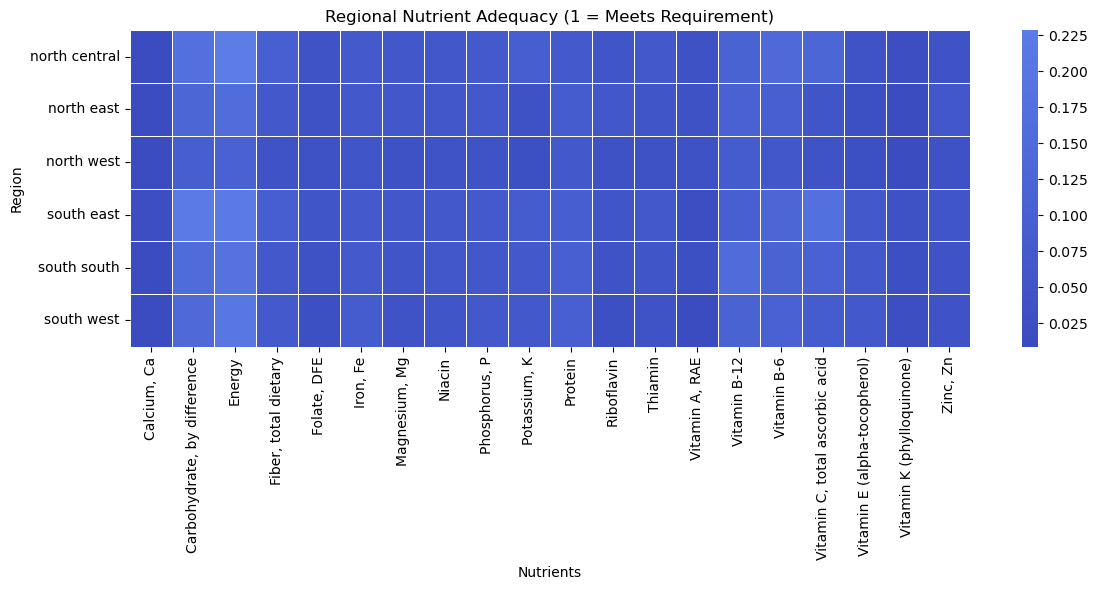

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

sns.heatmap(
    regional_adequacy,
    cmap='coolwarm',
    center=1,           # 1 = adequate
    annot=False,
    linewidths=0.5
)

plt.title('Regional Nutrient Adequacy (1 = Meets Requirement)')
plt.xlabel('Nutrients')
plt.ylabel('Region')
plt.tight_layout()
plt.show()

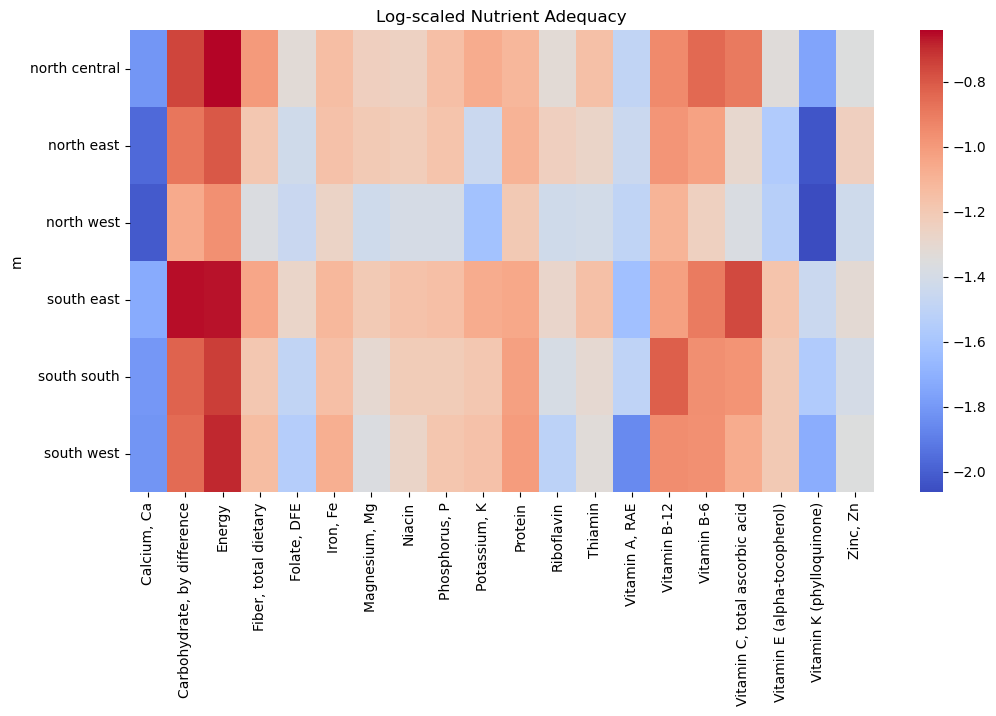

In [27]:
import numpy as np

log_adequacy = np.log10(regional_adequacy)

plt.figure(figsize=(12, 6))

sns.heatmap(
    log_adequacy,
    cmap='coolwarm',   # great for gradients
    annot=False
)

plt.title('Log-scaled Nutrient Adequacy')
plt.show()

# Policy 1 Simulation: Food Subsidy Impact

In [28]:
foods = ["Milk powder", "Green Leaves", "Plantains", "Fish", "Rice", "Eggs"]

nutrient_map = {
    "Milk powder": ["Calcium", "Magnesium"],
    "Green Leaves": ["Vitamin A", "Folate"],
    "Plantains": ["Vitamin K"],
    "Fish": ["Vitamin K"],
    "Rice": ["Folate"],
    "Eggs": ["Riboflavin"]
}

In [29]:
subsidies = [0.03, 0.05, 0.08, 0.10]
elasticity = -0.8

multiplier=1+(−ϵ⋅subsidy)

In [30]:
def consumption_multiplier(subsidy, elasticity=-0.8):
    return 1 + (-elasticity * subsidy)

In [32]:
# baseline adequacy (example structure)
# index = nutrients, values = adequacy %
baseline = {
    "Calcium": 0.015,
    "Magnesium": 0.05,
    "Vitamin A": 0.03,
    "Folate": 0.045,
    "Vitamin K": 0.017,
    "Riboflavin": 0.045
}

In [33]:
import pandas as pd

results = pd.DataFrame(index=baseline.keys(), columns=subsidies)

for s in subsidies:
    mult = consumption_multiplier(s)
    
    new_vals = {}
    for nutrient in baseline:
        # assume nutrient increases proportional to relevant food
        new_vals[nutrient] = baseline[nutrient] * mult
    
    results[s] = pd.Series(new_vals)

results.columns = ["3%", "5%", "8%", "10%"]

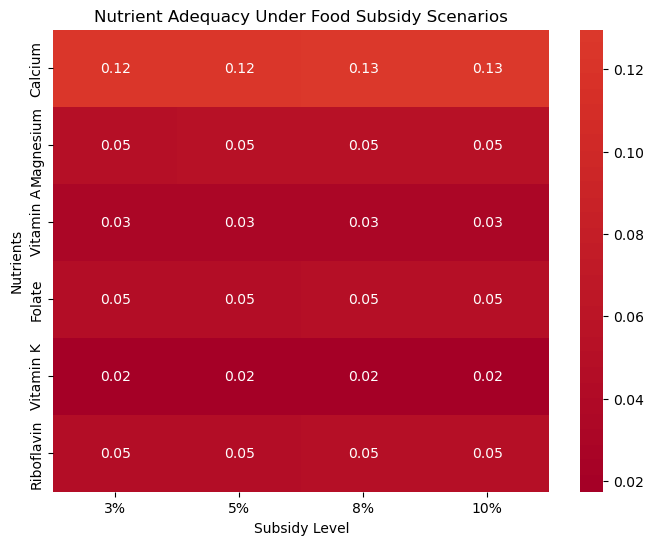

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(
    results,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",   # red → yellow → green
    center=0.5       # if normalized to adequacy = 1
)

plt.title("Nutrient Adequacy Under Food Subsidy Scenarios")
plt.xlabel("Subsidy Level")
plt.ylabel("Nutrients")

plt.show()